In [1]:
import numpy as np 
np.random.seed(42)

approximate the fucntion $y = x^2$

Case 1 : single hidden layer of width 3+1(bias)

In [2]:
np.random.seed(42)
W1 = np.random.rand(1, 3)
print(W1)

[[0.37454012 0.95071431 0.73199394]]


In [3]:
np.random.seed(42)
W2 = np.random.rand(4,1)
print(W2)

[[0.37454012]
 [0.95071431]
 [0.73199394]
 [0.59865848]]


In [4]:
# 5  random inputs x
np.random.seed(42)
xs = np.random.rand(50, 1)
print(f"x input vals:")
print(xs)

y_true = xs**2
print(f"y_true vals:")
print(y_true)

x input vals:
[[0.37454012]
 [0.95071431]
 [0.73199394]
 [0.59865848]
 [0.15601864]
 [0.15599452]
 [0.05808361]
 [0.86617615]
 [0.60111501]
 [0.70807258]
 [0.02058449]
 [0.96990985]
 [0.83244264]
 [0.21233911]
 [0.18182497]
 [0.18340451]
 [0.30424224]
 [0.52475643]
 [0.43194502]
 [0.29122914]
 [0.61185289]
 [0.13949386]
 [0.29214465]
 [0.36636184]
 [0.45606998]
 [0.78517596]
 [0.19967378]
 [0.51423444]
 [0.59241457]
 [0.04645041]
 [0.60754485]
 [0.17052412]
 [0.06505159]
 [0.94888554]
 [0.96563203]
 [0.80839735]
 [0.30461377]
 [0.09767211]
 [0.68423303]
 [0.44015249]
 [0.12203823]
 [0.49517691]
 [0.03438852]
 [0.9093204 ]
 [0.25877998]
 [0.66252228]
 [0.31171108]
 [0.52006802]
 [0.54671028]
 [0.18485446]]
y_true vals:
[[1.40280301e-01]
 [9.03857692e-01]
 [5.35815131e-01]
 [3.58391981e-01]
 [2.43418162e-02]
 [2.43342904e-02]
 [3.37370600e-03]
 [7.50261116e-01]
 [3.61339257e-01]
 [5.01366775e-01]
 [4.23721405e-04]
 [9.40725121e-01]
 [6.92960750e-01]
 [4.50878979e-02]
 [3.30603187e-02]
 [

In [5]:
# forward pass for each data point
ys = []
lr = 0.001
i = 1
for x in xs:
    a = W1.T @ x
    h = np.tanh(a)
    h = np.append(1, h)  # add bias term
    # print(h)
    y = W2.T @ h
    ys.append(y)

    # loss = (y - x**2)**2/2
    loss = (y - y_true[i-1])**2/2
    print(f"loss after {i}: {loss}")

    # back pass
    dL_dy = y - y_true[i-1]
    dL_dh = W2 @ dL_dy
    dL_da = dL_dh[1:] * (1 - np.tanh(a)**2)
    dL_dW1 = x*dL_da.reshape(1, -1)
    dL_dW2 = dL_dy*h.reshape(-1, 1)

    # update weights
    W1 -= lr * dL_dW1
    W2 -= lr * dL_dW2

    print(f"Updated W1:")
    print(W1)
    print(f"Updated W2:")
    print(W2)
    i += 1

loss after 1: [0.30191042]
Updated W1:
[[0.3742688  0.95052615 0.73183218]]
Updated W2:
[[0.37376306]
 [0.95060601]
 [0.73172838]
 [0.59845063]]
loss after 2: [0.23125352]
Updated W1:
[[0.37372586 0.950297   0.73158531]]
Updated W2:
[[0.37308298]
 [0.95037374]
 [0.73124002]
 [0.59804144]]
loss after 3: [0.33919819]
Updated W1:
[[0.37319371 0.95001568 0.73131118]]
Updated W2:
[[0.37225933]
 [0.95015388]
 [0.73074454]
 [0.5976382 ]]
loss after 4: [0.35677765]
Updated W1:
[[0.37273642 0.94974393 0.73106021]]
Updated W2:
[[0.37141461]
 [0.94996823]
 [0.73030999]
 [0.59729032]]
loss after 5: [0.16676347]
Updated W1:
[[0.37265112 0.94967955 0.73100708]]
Updated W2:
[[0.37083709]
 [0.94993469]
 [0.73022503]
 [0.59722473]]
loss after 6: [0.16638725]
Updated W1:
[[0.37256592 0.94961526 0.73095403]]
Updated W2:
[[0.37026023]
 [0.94990119]
 [0.73014019]
 [0.59715923]]
loss after 7: [0.10260849]
Updated W1:
[[0.37254094 0.94959611 0.73093835]]
Updated W2:
[[0.36980722]
 [0.94989139]
 [0.73011523]


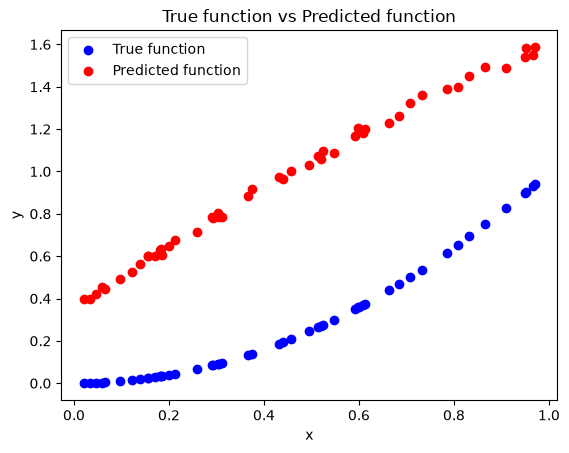

In [6]:
# plot scatter plot function ytrue = x^2 and predicted y 
import matplotlib.pyplot as plt
plt.scatter(xs, y_true, label='True function', color='blue')
plt.scatter(xs, ys, label='Predicted function', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True function vs Predicted function')
plt.legend()

In [7]:
for epoch in range(100):
    total_loss = 0
    ys = []
    i=0
    for x in xs:
        i += 1
        a = W1.T @ x
        hidden = np.tanh(a)
        h = np.append(1, hidden)

        y = W2.T @ h

        error = y - y_true[i-1]
        total_loss += float(0.5 * error**2)
        ys.append(y)

        dL_dy = error
        dL_dW2 = dL_dy * h.reshape(-1, 1)

        # dL_dh = W2 * dL_dy
        # dL_da = dL_dh[1:] * (1 - hidden**2)
        # dL_dW1 = x * dL_da.reshape(1, -1)

        dL_dh = (W2 * dL_dy).ravel()
        dL_da = dL_dh[1:] * (1 - hidden**2)
        dL_dW1 = x.reshape(1, 1) * dL_da.reshape(1, -1)

        W1 -= lr * dL_dW1
        # W2 -= lr * dL_dW2
        W2 -= lr * dL_dW2

    if epoch % 10 == 0:
        print(epoch, total_loss / len(xs))

0 0.20529966990692836
10 0.048281272239127225
20 0.014653153861239028
30 0.007067754357460818
40 0.00528023278653994
50 0.004815449282137872
60 0.004658508670155217
70 0.004576675121736051
80 0.004516175771809109
90 0.004464344353768678


/tmp/ipykernel_38417/1808851904.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  total_loss += float(0.5 * error**2)


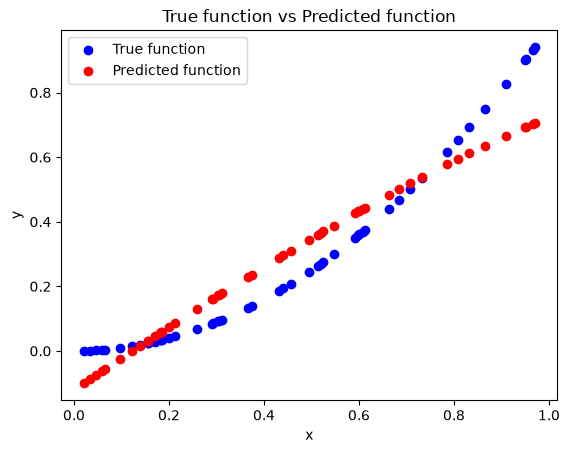

In [8]:
# plot scatter plot function ytrue = x^2 and predicted y 
import matplotlib.pyplot as plt
plt.scatter(xs, y_true, label='True function', color='blue')
plt.scatter(xs, ys, label='Predicted function', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True function vs Predicted function')
plt.legend()

Case 2: two hidden layers of width 3+1(bias)

In [9]:
np.random.seed(42)
W1 = np.random.rand(1, 3)
np.random.seed(42)
W2 = np.random.rand(4,3)
np.random.seed(42)
W3 = np.random.rand(4,1)

print(f"W1: {W1}")
print(f"W2: {W2}")
print(f"W3: {W3}")

W1: [[0.37454012 0.95071431 0.73199394]]
W2: [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]]
W3: [[0.37454012]
 [0.95071431]
 [0.73199394]
 [0.59865848]]


In [10]:
# 5 random inputs x
np.random.seed(42)
xs = np.random.rand(50, 1)
print(f"x input vals:")
print(xs)

y_true = xs**2
print(f"y_true vals:")
print(y_true)

x input vals:
[[0.37454012]
 [0.95071431]
 [0.73199394]
 [0.59865848]
 [0.15601864]
 [0.15599452]
 [0.05808361]
 [0.86617615]
 [0.60111501]
 [0.70807258]
 [0.02058449]
 [0.96990985]
 [0.83244264]
 [0.21233911]
 [0.18182497]
 [0.18340451]
 [0.30424224]
 [0.52475643]
 [0.43194502]
 [0.29122914]
 [0.61185289]
 [0.13949386]
 [0.29214465]
 [0.36636184]
 [0.45606998]
 [0.78517596]
 [0.19967378]
 [0.51423444]
 [0.59241457]
 [0.04645041]
 [0.60754485]
 [0.17052412]
 [0.06505159]
 [0.94888554]
 [0.96563203]
 [0.80839735]
 [0.30461377]
 [0.09767211]
 [0.68423303]
 [0.44015249]
 [0.12203823]
 [0.49517691]
 [0.03438852]
 [0.9093204 ]
 [0.25877998]
 [0.66252228]
 [0.31171108]
 [0.52006802]
 [0.54671028]
 [0.18485446]]
y_true vals:
[[1.40280301e-01]
 [9.03857692e-01]
 [5.35815131e-01]
 [3.58391981e-01]
 [2.43418162e-02]
 [2.43342904e-02]
 [3.37370600e-03]
 [7.50261116e-01]
 [3.61339257e-01]
 [5.01366775e-01]
 [4.23721405e-04]
 [9.40725121e-01]
 [6.92960750e-01]
 [4.50878979e-02]
 [3.30603187e-02]
 [

In [11]:
# forward pass for each data point
ys = []
total_loss = 0
lr = 0.001
i=0
for x in xs:
    a1 = W1.T @ x
    hidden1 = np.tanh(a1)
    h1 = np.append(1, hidden1)

    a2 = W2.T @ h1 
    hidden2 = np.tanh(a2)
    h2 = np.append(1, hidden2)

    y = W3.T @ h2
    
    error = y - y_true[i]
    print(y, y_true[i], error)
    total_loss += float(0.5 * error**2)
    ys.append(y)
    print(f"loss after {i}: {total_loss}")

    # backpropagation
    dL_dy = error
    dL_dW3 = dL_dy * h2.reshape(-1, 1)

    dL_dh2 = (W3 * dL_dy).ravel()
    dL_da2 = dL_dh2[1:] * (1 - hidden2**2)
    dL_dW2 = h1.reshape(-1, 1) @ dL_da2.reshape(1, -1)

    dL_da1 = (W2 @ dL_da2).ravel()[1:] * (1 - hidden1**2)
    dL_dW1 = x.reshape(1, 1) @ dL_da1.reshape(1, -1)

    W1 -= lr * dL_dW1
    W2 -= lr * dL_dW2
    W3 -= lr * dL_dW3

    print(f"Updated W1: {W1}")
    print(f"Updated W2: {W2}")
    print(f"Updated W3: {W3}")
    i+=1

[2.05713639] [0.1402803] [1.91685609]
loss after 0: 1.837168631307364
Updated W1: [[0.37423462 0.95051551 0.73158068]]
Updated W2: [[0.37333747 0.9503366  0.73165465]
 [0.59849087 0.155966   0.15594723]
 [0.0576726  0.86604706 0.60099906]
 [0.70775088 0.02048346 0.96981909]]
Updated W3: [[0.37262326]
 [0.94959648]
 [0.73035527]
 [0.59704977]]
[2.35556018] [0.90385769] [1.45170249]
loss after 1: 2.8908886892180683
Updated W1: [[0.37393181 0.95041696 0.73129401]]
Updated W2: [[0.37279721 0.95018778 0.73156486]
 [0.59830637 0.15591518 0.15591657]
 [0.05728465 0.8659402  0.60093458]
 [0.7074259  0.02039394 0.96976509]]
Updated W3: [[0.37117156]
 [0.94846445]
 [0.7290093 ]
 [0.59567532]]
[2.2692838] [0.53581513] [1.73346867]
loss after 2: 4.393345496828987
Updated W1: [[0.37357296 0.95026446 0.73089977]]
Updated W2: [[0.37201181 0.94996866 0.7314121 ]
 [0.59809661 0.15585666 0.15587577]
 [0.05681213 0.86580837 0.60084267]
 [0.70704151 0.0202867  0.96969032]]
Updated W3: [[0.36943809]
 [0.94

/tmp/ipykernel_38417/4022713071.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  total_loss += float(0.5 * error**2)


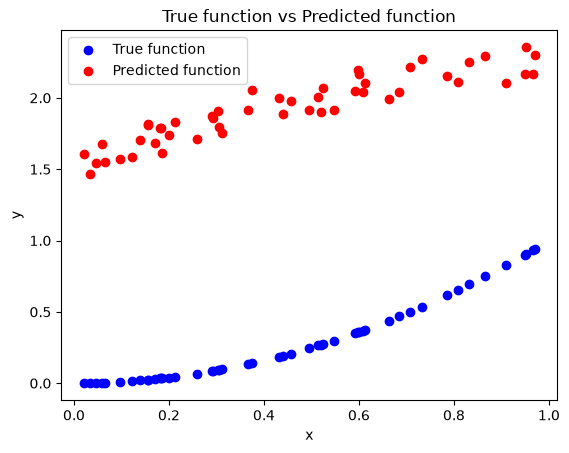

In [12]:
# plot scatter plot function ytrue = x^2 and predicted y 
import matplotlib.pyplot as plt
plt.scatter(xs, y_true, label='True function', color='blue')
plt.scatter(xs, ys, label='Predicted function', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True function vs Predicted function')
plt.legend()

In [13]:
for epoch in range(100):
    total_loss = 0
    ys = []
    i=0
    for x in xs:
        a1 = W1.T @ x
        hidden1 = np.tanh(a1)
        h1 = np.append(1, hidden1)

        a2 = W2.T @ h1 
        hidden2 = np.tanh(a2)
        h2 = np.append(1, hidden2)

        y = W3.T @ h2
        
        error = y - y_true[i]
        # print(y, y_true[i], error)
        total_loss += float(0.5 * error**2)
        ys.append(y)

        # backpropagation
        dL_dy = error
        dL_dW3 = dL_dy * h2.reshape(-1, 1)

        dL_dh2 = (W3 * dL_dy).ravel()
        dL_da2 = dL_dh2[1:] * (1 - hidden2**2)
        dL_dW2 = h1.reshape(-1, 1) @ dL_da2.reshape(1, -1)

        dL_da1 = (W2 @ dL_da2).ravel()[1:] * (1 - hidden1**2)
        dL_dW1 = x.reshape(1, 1) @ dL_da1.reshape(1, -1)

        W1 -= lr * dL_dW1
        W2 -= lr * dL_dW2
        W3 -= lr * dL_dW3

    if epoch % 10 == 0:
        print(epoch, total_loss / len(xs))

0 1.1836572876884637
10 0.05875520456547527
20 0.007619146220027976
30 0.004729535603000042
40 0.0043516541297876086
50 0.004124085597243566
60 0.00391873560684792
70 0.003727209356381069
80 0.0035479186464268714
90 0.0033798120455058424


/tmp/ipykernel_38417/3667918010.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  total_loss += float(0.5 * error**2)


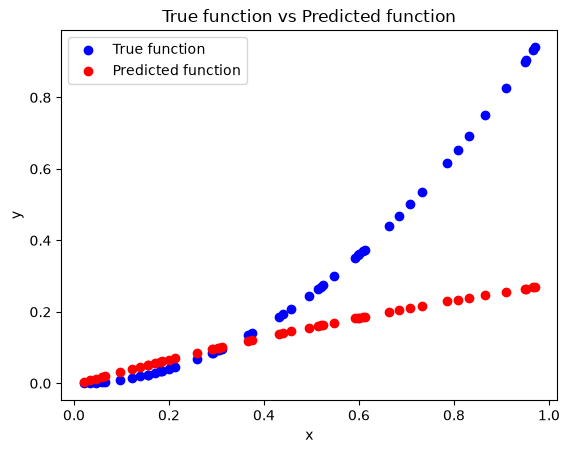

In [14]:
# plot scatter plot function ytrue = x^2 and predicted y 
import matplotlib.pyplot as plt
plt.scatter(xs, y_true, label='True function', color='blue')
plt.scatter(xs, ys, label='Predicted function', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True function vs Predicted function')
plt.legend()